In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
# TOTO ZABRÁNÍ PÁDU NA GPU (Skryje GPU před PyTorchem a vynutí čisté CPU)
os.environ["CUDA_VISIBLE_DEVICES"] = ""
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
import torch
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
import pytorch_lightning as pl
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import ParameterGrid
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

train_data_pd = pd.read_csv('data/train.csv', index_col=0)
train_data_pd.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
import torchmetrics

class TitanicClassifier(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim=64, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        self.criterion = nn.BCEWithLogitsLoss()
        
        # Inicializace historie pro grafy
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        
        self.train_acc = torchmetrics.Accuracy(task="binary")
        self.val_acc = torchmetrics.Accuracy(task="binary")

    def forward(self, x): 
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        # ZDE JE OPRAVA: squeeze(dim=1) zabrání smazání batch dimenze, pokud je batch_size = 1
        logits = self(x).squeeze(dim=1) 
        loss = self.criterion(logits, y.float())
        acc = self.train_acc(torch.sigmoid(logits), y.int())
        
        # Přidáno on_epoch=True pro správné zprůměrování na konci epochy
        self.log_dict({'train_loss': loss, 'train_acc': acc}, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze(dim=1)
        loss = self.criterion(logits, y.float())
        acc = self.val_acc(torch.sigmoid(logits), y.int())
        
        self.log_dict({'val_loss': loss, 'val_acc': acc}, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        # Uložení zprůměrovaných hodnot za epochu pro grafy
        if 'train_loss' in self.trainer.callback_metrics:
            self.history['train_loss'].append(self.trainer.callback_metrics['train_loss'].item())
        if 'train_acc' in self.trainer.callback_metrics:
            self.history['train_acc'].append(self.trainer.callback_metrics['train_acc'].item())
        
    def on_validation_epoch_end(self):
        if 'val_loss' in self.trainer.callback_metrics:
            self.history['val_loss'].append(self.trainer.callback_metrics['val_loss'].item())
        if 'val_acc' in self.trainer.callback_metrics:
            self.history['val_acc'].append(self.trainer.callback_metrics['val_acc'].item())

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate)

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import torch
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import ParameterGrid
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# =====================================================================
# 1. FUNKCE PRO NEURONOVOU SÍŤ
# =====================================================================
def train_evaluate_nn(X_train_scaled, y_train, train_indices, val_indices):
    print("\n" + "="*50)
    print("🧠 TRÉNINK NEURONOVÉ SÍTĚ (PyTorch Lightning)")
    print("="*50)
    
    full_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), 
                                 torch.tensor(y_train.values, dtype=torch.float32))
    
    train_ds = torch.utils.data.Subset(full_dataset, train_indices)
    val_ds = torch.utils.data.Subset(full_dataset, val_indices)
    
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32)

    early_stop_callback = EarlyStopping(monitor='val_loss', min_delta=0.005, patience=50, verbose=False, mode='min')
    
    model = TitanicClassifier(input_dim=X_train_scaled.shape[1])
    trainer = pl.Trainer(max_epochs=150, accelerator="cpu", enable_model_summary=False, 
                         callbacks=[early_stop_callback], logger=False, enable_progress_bar=False)
    
    trainer.fit(model, train_loader, val_loader)

    best_val_acc = max(model.history['val_acc']) * 100
    print(f"✅ Hotovo! Nejlepší přesnost na validační sadě: {best_val_acc:.2f} %")
    
    return best_val_acc, model

# =====================================================================
# 2. FUNKCE PRO SVM
# =====================================================================
def train_evaluate_svm(X_train, y_train, X_val, y_val):
    print("\n" + "="*50)
    print("📈 TRÉNINK SVM (Support Vector Machine)")
    print("="*50)
    
    param_grid = {
        'C': [0.1, 1, 10, 100],            
        'gamma': [1, 0.1, 0.01, 0.001],    
        'kernel': ['rbf', 'linear']        
    }
    grid = ParameterGrid(param_grid)
    
    best_acc = 0
    best_params = None
    best_model = None
    
    for params in grid:
        svm_model = SVC(**params, random_state=42)
        svm_model.fit(X_train, y_train)
        acc = accuracy_score(y_val, svm_model.predict(X_val)) * 100
        
        if acc > best_acc:
            best_acc = acc
            best_params = params
            best_model = svm_model
            
    print(f"✅ Hotovo! Nejlepší přesnost: {best_acc:.2f} % (Parametry: {best_params})")
    return best_acc, best_model

# =====================================================================
# 3. FUNKCE PRO KNN
# =====================================================================
def train_evaluate_knn(X_train, y_train, X_val, y_val):
    print("\n" + "="*50)
    print("📍 TRÉNINK KNN (K-Nearest Neighbors)")
    print("="*50)
    
    best_acc = 0
    best_k = 1
    best_model = None 
    
    for k in range(1, 31):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        acc = accuracy_score(y_val, knn.predict(X_val)) * 100
        
        if acc > best_acc:
            best_acc = acc
            best_k = k
            best_model = knn
            
    print(f"✅ Hotovo! Nejlepší přesnost: {best_acc:.2f} % (K={best_k})")
    return best_acc, best_model

# =====================================================================
# 4. FUNKCE PRO VYKRESLENÍ VÝSLEDKŮ A POROVNÁNÍ
# =====================================================================
def plot_results(nn_model, nn_acc, svm_acc, knn_acc):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(nn_model.history['train_loss'], label='Train Loss')
    plt.plot(nn_model.history['val_loss'], label='Val Loss')
    plt.title('NN: Vývoj Loss v čase')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(nn_model.history['train_acc'], label='Train Acc')
    plt.plot(nn_model.history['val_acc'], label='Val Acc')
    plt.title('NN: Vývoj Přesnosti v čase')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(1, 3, 3)
    modely = ['KNN', 'Neuronová síť', 'SVM']
    skore = [knn_acc, nn_acc, svm_acc]
    barvy = ['#1f77b4', '#d62728', '#9467bd']
    
    bars = plt.bar(modely, skore, color=barvy, width=0.5)
    plt.title('Férové porovnání přesnosti')
    plt.ylim(0, 100)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# =====================================================================
# 🚀 HLAVNÍ FUNKCE (TUTO BUDEŠ VOLAT)
# =====================================================================
def run_all_experiments(train_clean, test_clean):
    y_train = train_clean['Survived']
    X_train = train_clean.drop(columns=['Survived'])
    X_test = test_clean

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    num_samples = len(X_train_scaled)
    val_size = int(0.1 * num_samples) # Tvých 15 % je super pro lepší stabilitu výsledku!
    indices = np.random.permutation(num_samples) 
    train_indices, val_indices = indices[val_size:], indices[:val_size]

    X_train_fair = X_train_scaled[train_indices]
    y_train_fair = y_train.values[train_indices]
    X_val_fair = X_train_scaled[val_indices]
    y_val_fair = y_train.values[val_indices]

    # Trénink všech 3 modelů
    nn_acc, nn_model = train_evaluate_nn(X_train_scaled, y_train, train_indices, val_indices)
    svm_acc, svm_model = train_evaluate_svm(X_train_fair, y_train_fair, X_val_fair, y_val_fair)
    knn_acc, knn_model = train_evaluate_knn(X_train_fair, y_train_fair, X_val_fair, y_val_fair)

    # ---------------------------------------------------------
    # KORUNOVACE VÍTĚZE 
    # ---------------------------------------------------------
    print("\n" + "="*50)
    vysledky = {'Neuronová síť': nn_acc, 'SVM': svm_acc, 'KNN': knn_acc}
    vitez = max(vysledky, key=vysledky.get)
    print(f"🏆 Lokálním vítězem (na validační sadě) je: {vitez} s přesností {vysledky[vitez]:.2f} %")
    print("="*50)

    # ---------------------------------------------------------
    # VYMÁČKNUTÍ PREDIKCÍ A ULOŽENÍ 3 CSV SOUBORŮ
    # ---------------------------------------------------------
    # Příprava společných ID pasažérů
    passenger_ids = test_clean.index if 'PassengerId' not in test_clean.columns else test_clean['PassengerId']
    
    # 1. Neuronová síť (inference vyžaduje torch tensors)
    tensor_X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
    nn_model.eval()
    with torch.no_grad():
        nn_preds = (torch.sigmoid(nn_model(tensor_X_test)).squeeze() >= 0.5).int().numpy()
    pd.DataFrame({'PassengerId': passenger_ids, 'Survived': nn_preds}).to_csv('submission_NN.csv', index=False)
    
    # 2. SVM
    svm_preds = svm_model.predict(X_test_scaled)
    pd.DataFrame({'PassengerId': passenger_ids, 'Survived': svm_preds}).to_csv('submission_SVM.csv', index=False)
    
    # 3. KNN
    knn_preds = knn_model.predict(X_test_scaled)
    pd.DataFrame({'PassengerId': passenger_ids, 'Survived': knn_preds}).to_csv('submission_KNN.csv', index=False)

    print("📁 Predikce od všech 3 modelů byly úspěšně uloženy do samostatných CSV souborů!")

    # Vykreslení výsledků na závěr
    plot_results(nn_model, nn_acc, svm_acc, knn_acc)

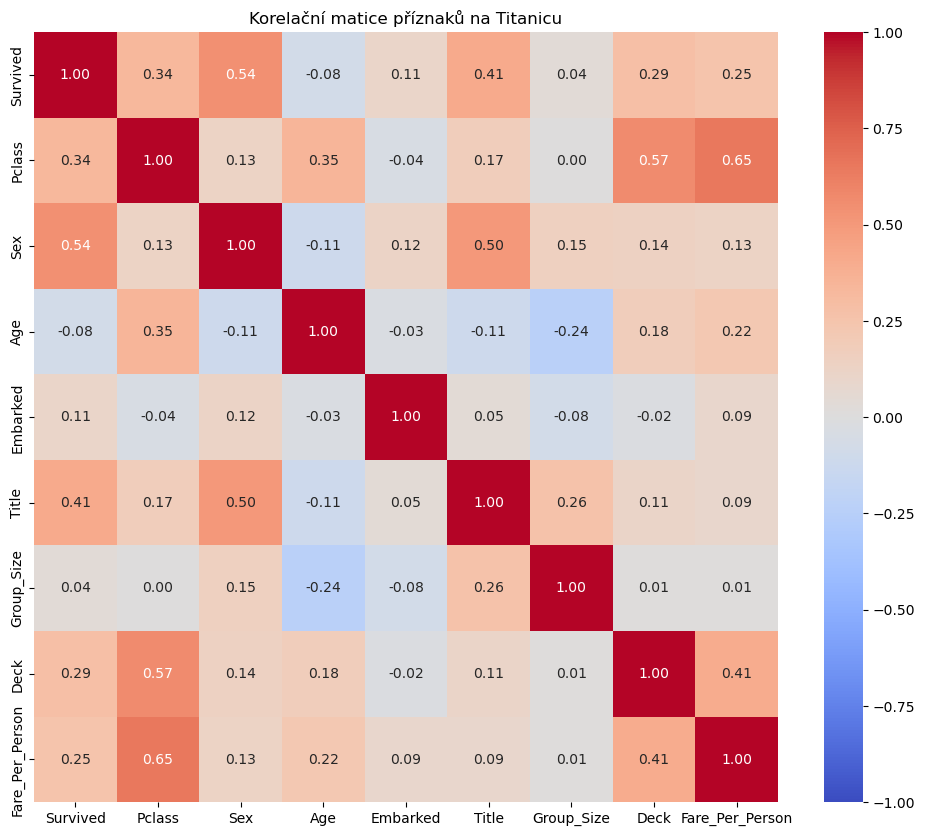

In [4]:
import pandas as pd
train_raw = pd.read_csv('data/train.csv', index_col=0)
test_raw = pd.read_csv('data/test.csv', index_col=0)
def preprocess_titanic_data(df, is_train=True, age_medians=None):
    df_clean = df.copy()

    # --- TVŮJ PŮVODNÍ PREPROCESSING ---
    df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
    df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    # 0. Pclass: Obrácení tříd (Tvůj nápad: vyšší hodnota = lepší třída)
    # 1. třída -> 3, 2. třída -> 2, 3. třída -> 1
    df_clean['Pclass'] = df_clean['Pclass'].map({1: 3, 2: 2, 3: 1})

    if is_train:
        df_clean = df_clean.dropna(subset=['Embarked'])
    else: # Vráceno: ošetření pro Kaggle test sadu
        df_clean['Embarked'] = df_clean['Embarked'].fillna(0)

    df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df_clean['Title'] = df_clean['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df_clean['Title'] = df_clean['Title'].replace('Mme', 'Mrs')
    rare_titles = ['Don', 'Rev', 'Dr', 'Major', 'Lady', 'Sir', 'Col', 'Capt', 'the', 'Jonkheer', 'Countess', 'Dona'] 
    df_clean['Title'] = df_clean['Title'].replace(rare_titles, 'Rare')
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
    df_clean['Title'] = df_clean['Title'].map(title_mapping).fillna(0) 
    df_clean.drop(columns=['Name'], inplace=True) 

    pocty_listku = df_clean['Ticket'].value_counts()
    df_clean['Group_Size'] = df_clean['Ticket'].map(pocty_listku)
    df_clean.drop(columns=['Ticket'], inplace=True) 

    # Kajuty - Tady perfektně využíváš to, že nula = nemá kajutu = malá šance na přežití
    df_clean['Deck'] = df_clean['Cabin'].str.extract(r'([A-Za-z])', expand=False)
    cabin_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "T": 8}
    df_clean['Deck'] = df_clean['Deck'].map(cabin_mapping).fillna(0) 
    df_clean.drop(columns=['Cabin'], inplace=True) 

    if is_train:
        age_medians = df_clean.groupby('Title')['Age'].median().to_dict()
        df_clean['Age'] = df_clean['Age'].fillna(df_clean['Title'].map(age_medians))
    else: # Vráceno: doplňování věku z mediánů tréninku pro testovací sadu
        df_clean['Age'] = df_clean['Age'].fillna(df_clean['Title'].map(age_medians))

    if not is_train:
        df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

    # --- TVÉ NOVÉ NÁPADY ---
    
    # Výpočet reálné ceny na osobu
    df_clean['Fare_Per_Person'] = df_clean['Fare'] / df_clean['Group_Size']
    
    # Dobrá úvaha (volitelné): Protože už máme Fare_Per_Person a Group_Size, 
    # původní Fare by mohlo modely (zvlášť ty lineární) mást, protože by to byla duplicitní informace.
    df_clean.drop(columns=['Fare'], inplace=True)
    df_clean.drop(columns=['SibSp', 'Parch'], inplace=True) # nepřináší novou informaci, protože už máme Group_Size

    if is_train:
        return df_clean, age_medians
    return df_clean

# # 1. Zpracování trénovacích dat (získáme vyčištěný DataFrame a mediány věku)
train_clean, learned_age_medians = preprocess_titanic_data(train_raw, is_train=True)
train_clean.head(20)

číselná_data = train_clean.select_dtypes(include=['int64', 'float64'])

# 2. Samotný výpočet korelační matice (Pearsonův koeficient)
korelacni_matice = číselná_data.corr()

# 3. Vizualizace pomocí teplotní mapy
plt.figure(figsize=(12, 10)) # Nastavení velikosti grafu

# Vykreslení heatmapy:
# annot=True zobrazí čísla, cmap nastaví barvy (od modré po červenou), 
# fmt=".2f" zaokrouhlí na 2 desetinná místa
sns.heatmap(korelacni_matice, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Korelační matice příznaků na Titanicu')
plt.show()
# # 2. Zpracování testovacích dat (předáme funkci naučené mediány z tréninku)
# test_clean = preprocess_titanic_data(test_raw, is_train=False, age_medians=learned_age_medians)


🧠 TRÉNINK NEURONOVÉ SÍTĚ (PyTorch Lightning)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/luky/.local/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


✅ Hotovo! Nejlepší přesnost na validační sadě: 95.45 %

📈 TRÉNINK SVM (Support Vector Machine)
✅ Hotovo! Nejlepší přesnost: 92.05 % (Parametry: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'})

📍 TRÉNINK KNN (K-Nearest Neighbors)
✅ Hotovo! Nejlepší přesnost: 93.18 % (K=8)

🏆 Lokálním vítězem (na validační sadě) je: Neuronová síť s přesností 95.45 %
📁 Predikce od všech 3 modelů byly úspěšně uloženy do samostatných CSV souborů!


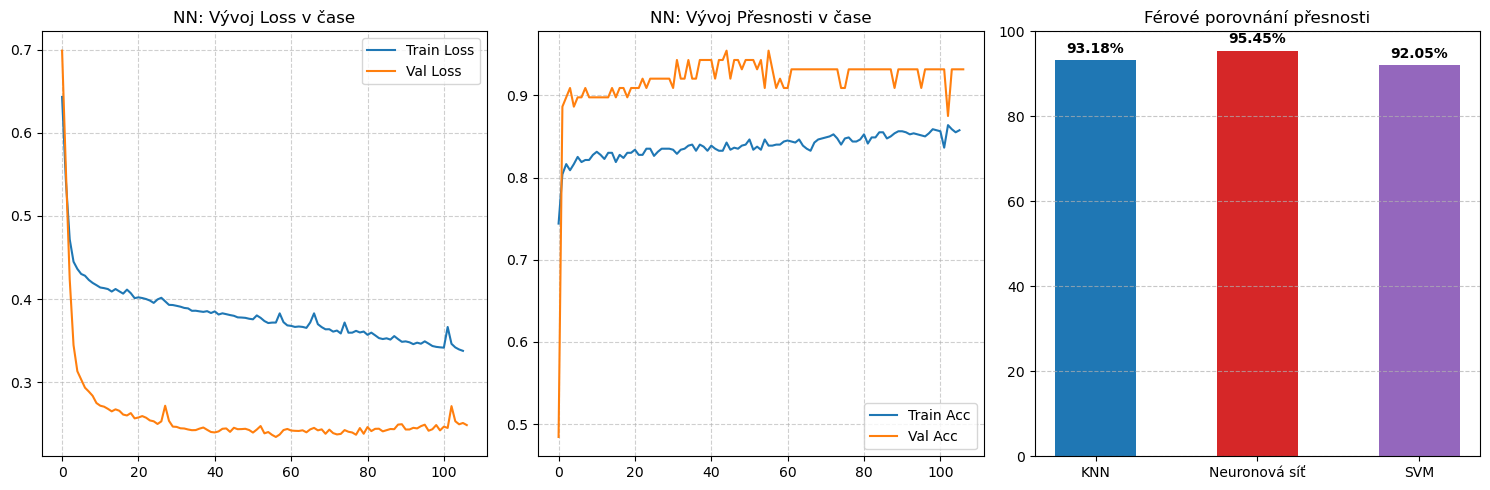

In [5]:
# 1. Zpracování dat tvou (nově upravenou) funkcí
train_clean, learned_age_medians = preprocess_titanic_data(train_raw, is_train=True)
test_clean = preprocess_titanic_data(test_raw, is_train=False, age_medians=learned_age_medians)

# 2. Spuštění celého experimentu a vykreslení!
run_all_experiments(train_clean, test_clean)